## 탐색적 데이터 분석 (EDA) 


> **"GNN이 필요하다는 것을 데이터로 직접 보여준다"**

분석은 두 파트로 구성됩니다:

### Part 1 — 비즈니스 문제 발견
- H&M 구매 데이터의 구조적 불균형 (파레토 법칙) 확인
- 신상품의 판매 집중 구간 분석 (제품 수명 주기)
- **결론: 기존 추천 시스템이 왜 실패하는가**

### Part 2 — GNN 모델링 전 데이터 탐색
- 고객-상품 구매 그래프의 희소성(Sparsity) 측정
- 허브(Hub) 고객·상품 분석 → GNN이 잘 동작하는 이유
- 색상·패턴 동시 구매 분석 → 스타일 DNA 개념 검증

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler

import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

from sklearn.cluster import KMeans, DBSCAN
from mlxtend.frequent_patterns import association_rules, apriori

In [4]:
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')
customers = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\customers.parquet')
articles = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\articles.parquet')

---

### <CENTER> 1. EDA

---

In [ ]:
# Sparsity 계산
n_users = transactions['customer_id'].nunique()
n_items = transactions['article_id'].nunique()
n_interactions = len(transactions)

sparsity = 1.0 - (n_interactions / (n_users * n_items))

print(f"총 유저 수: {n_users:,}명")
print(f"총 아이템 수: {n_items:,}개")
print(f"User-Item 행렬의 희소성(Sparsity): {sparsity * 100:.4f}%")

총 유저 수: 1,360,919명
총 아이템 수: 104,400개
User-Item 행렬의 희소성(Sparsity): 99.9781%


- H&M 데이터의 Sparsity는 99.9%입니다. 

- 기존의 행렬 분해(MF) 기법은 유저와 아이템 간의 '직접적인 1:1 상호작용(누가 뭘 샀나)'에만 의존하기 때문에 이 빈 공간을 채우기 어렵습니다.

-  반면 저희가 도입한 GNN은 단순히 누가 샀는지를 넘어, 아이템 간의 '코디 관계(A를 산 사람이 B도 샀다)'라는 복합적인 그래프 구조를 학습합니다. 

- 즉, 나와 직접 연결되지 않은 상품이라도, 이웃 고객의 코디 네트워크를 타고 넘어와 빈 공간을 영리하게 채워줄 수 있는 방법이라고 생각했습니다.

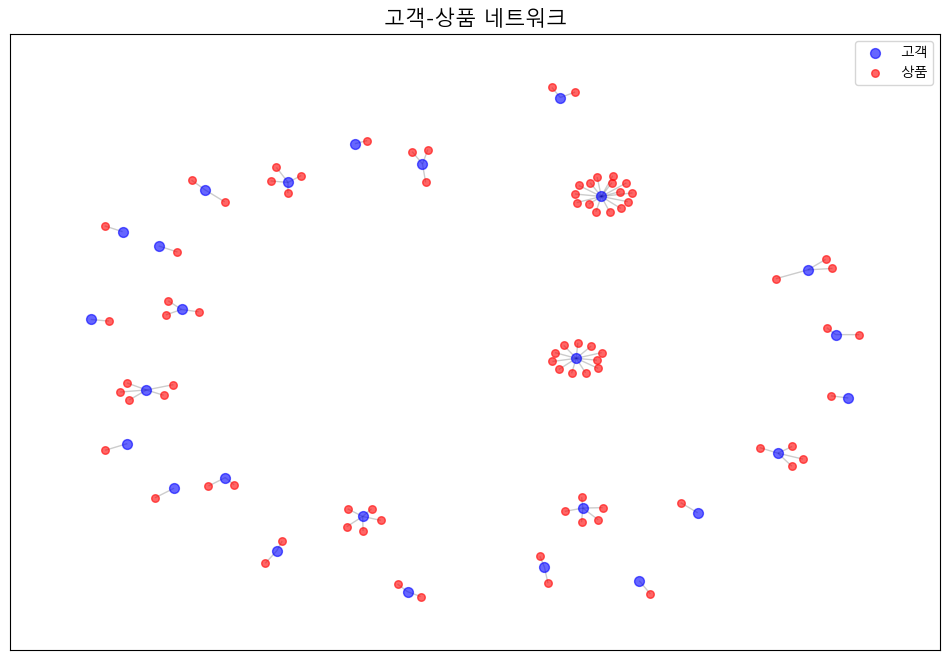

In [ ]:
import networkx as nx

# VIP 고객 1명과 그 주변 관계만 샘플링 (전체는 시각화 불가)
sample_transactions = transactions.head(100)
B = nx.Graph()

# Node 및 Edge 추가
B.add_nodes_from(sample_transactions['customer_id'], bipartite=0)
B.add_nodes_from(sample_transactions['article_id'], bipartite=1)
edges = list(zip(sample_transactions['customer_id'], sample_transactions['article_id']))
B.add_edges_from(edges)

# 시각화
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(B, seed=42)
nx.draw_networkx_nodes(B, pos, nodelist=sample_transactions['customer_id'].unique(), node_color='blue', node_size=50, alpha=0.6, label='고객')
nx.draw_networkx_nodes(B, pos, nodelist=sample_transactions['article_id'].unique(), node_color='red', node_size=30, alpha=0.6, label='상품')
nx.draw_networkx_edges(B, pos, alpha=0.2)
plt.title("고객-상품 네트워크", fontsize=15)
plt.legend()
plt.show()

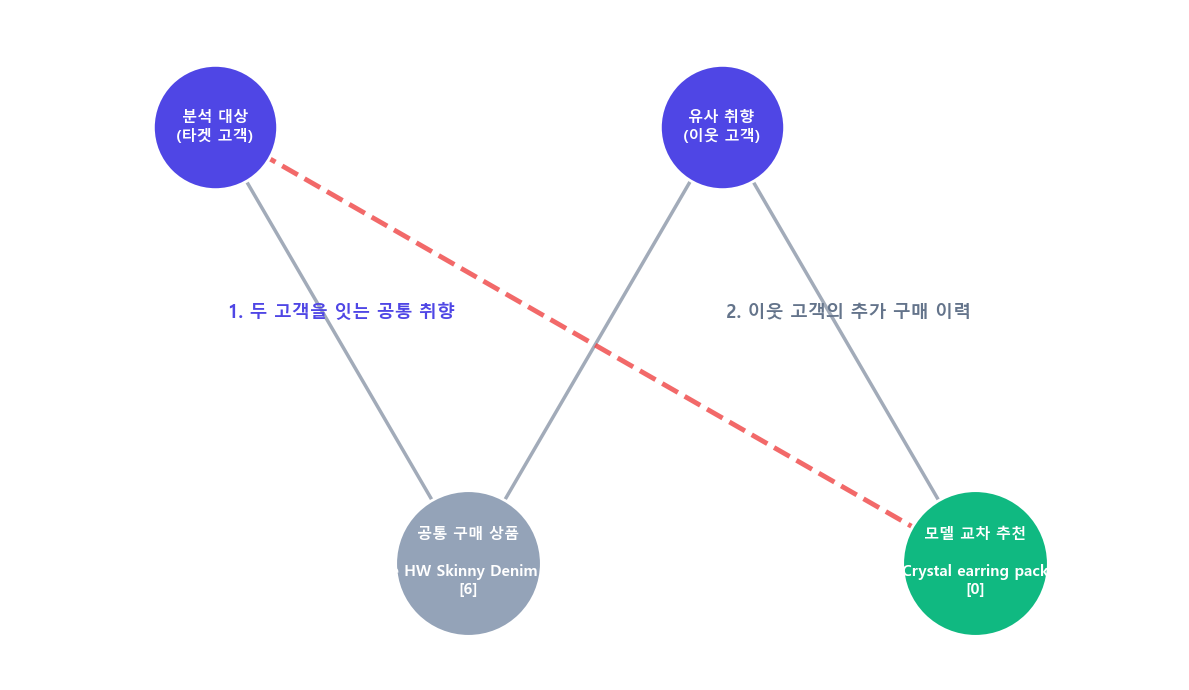

In [ ]:
import platform

# 한글깨짐 고딕 추가
if platform.system() == 'Darwin':
    font_name = 'AppleGothic'
else:
    font_name = 'Malgun Gothic'
    
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# GNN의 핵심인 징검다리(hub) 데이터 추출
# ==========================================
hub_item = transactions['article_id'].value_counts().index[0]

hub_buyers = transactions[transactions['article_id'] == hub_item]['customer_id'].unique()
vip_user = hub_buyers[0]     
other_user = hub_buyers[1]   

other_user_items = transactions[transactions['customer_id'] == other_user]['article_id'].unique()
target_items = [item for item in other_user_items if item != hub_item]
target_item = target_items[0] if len(target_items) > 0 else transactions['article_id'].unique()[1]

hub_info = articles[articles['article_id'] == hub_item].iloc[0]
target_info = articles[articles['article_id'] == target_item].iloc[0]

node_vip = "분석 대상\n(타겟 고객)"
node_neighbor = "유사 취향\n(이웃 고객)"

hub_name = str(hub_info['prod_name']).strip()
hub_cat = str(hub_info['product_group_name']).strip()
target_name = str(target_info['prod_name']).strip()
target_cat = str(target_info['product_group_name']).strip()

node_hub = f"공통 구매 상품\n\n{hub_name}\n[{hub_cat}]"
node_target = f"모델 교차 추천\n\n{target_name}\n[{target_cat}]"

# ==========================================
# GNN 설명용 논리적 그래프
# ==========================================
G = nx.Graph()

G.add_node(node_vip, pos=(0, 1.2), type='user')
G.add_node(node_neighbor, pos=(2, 1.2), type='user')
G.add_node(node_hub, pos=(1, 0.4), type='item')
G.add_node(node_target, pos=(3, 0.4), type='item_target')

G.add_edge(node_vip, node_hub)
G.add_edge(node_neighbor, node_hub)
G.add_edge(node_neighbor, node_target)

# ==========================================
# B2B 대시보드 스타일 시각화 
# ==========================================
plt.figure(figsize=(12, 7), facecolor='white') 
pos = nx.get_node_attributes(G, 'pos')

user_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'user']
item_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'item']
target_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'item_target']

nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color='#4F46E5', node_size=8000, edgecolors='white', linewidths=2)
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, node_color='#94A3B8', node_size=11000, edgecolors='white', linewidths=2)
nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, node_color='#10B981', node_size=11000, edgecolors='white', linewidths=2)

nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=2.5, alpha=0.6, edge_color='#64748B')

G.add_edge(node_vip, node_target)
nx.draw_networkx_edges(G, pos, edgelist=[(node_vip, node_target)], 
                       width=3.5, alpha=0.8, edge_color='#EF4444', style='dashed')


nx.draw_networkx_labels(G, pos, font_size=11, font_color='white', font_weight='bold', font_family=font_name)

plt.text(0.5, 0.85, "1. 두 고객을 잇는 공통 취향", fontsize=13, color='#4F46E5', ha='center', weight='bold')
plt.text(2.5, 0.85, "2. 이웃 고객의 추가 구매 이력", fontsize=13, color='#64748B', ha='center', weight='bold')

plt.title("", fontsize=19, fontweight='bold', pad=30)
plt.margins(0.2) 
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 장바구니(같은 날, 같은 고객) 단위 
basket_df = transactions.groupby(['customer_id', 't_dat'])['article_id'].apply(list).reset_index()

# 허브 분석 (장바구니 길이가 2 이상인 것만)
baskets = basket_df[basket_df['article_id'].map(len) >= 2]['article_id'].tolist()
print(f"2개 이상 구매된 장바구니 수: {len(baskets):,}개")
print("인사이트: 고객은 단일 품목이 아닌 '코디(세트)' 단위로 구매하며, 아이템 간의 연결성 분석이 매출과 직결됨을 의미함.")

2개 이상 구매된 장바구니 수: 6,300,832개
인사이트: 고객은 단일 품목이 아닌 '코디(세트)' 단위로 구매하며, 아이템 간의 연결성(Graph) 분석이 매출과 직결됨을 의미함.


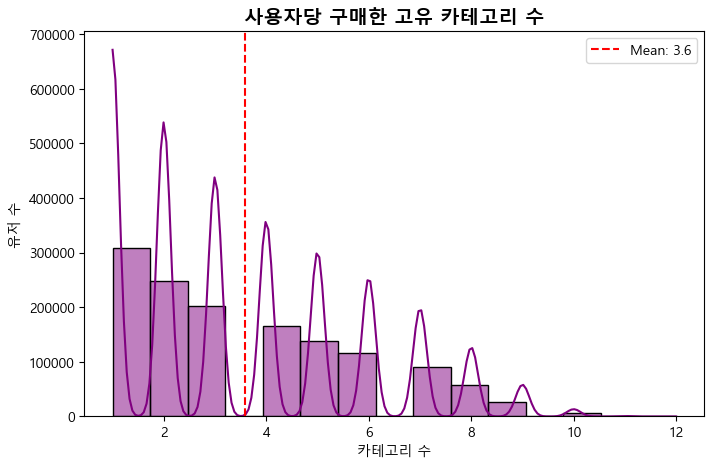

In [ ]:
# 고객이 구매한 고유 카테고리 수 분포
merged_eda = transactions.merge(articles[['article_id', 'product_group_name']], on='article_id')
cat_per_user = merged_eda.groupby('customer_id')['product_group_name'].nunique()

plt.figure(figsize=(8, 5))
sns.histplot(cat_per_user, bins=15, kde=True, color='purple')
plt.title('사용자당 구매한 고유 카테고리 수', fontsize=14, fontweight='bold')
plt.xlabel('카테고리 수')
plt.ylabel('유저 수')
plt.axvline(cat_per_user.mean(), color='red', linestyle='--', label=f'Mean: {cat_per_user.mean():.1f}')
plt.legend()
plt.show()

- 대부분의 고객이 2개 이상의 이종 카테고리를 넘나들며 구매합니다. 카테고리 장벽을 넘는 추천망이 필요합니다.

- 바지를 산 사람이 상의를 사고, 그 상의를 산 다른 사람이 모자를 사는 식의 연쇄 반응을 증명합니다.

In [17]:
# 고객별-아이템별 구매 횟수
repurchase_rates = transactions.groupby(['customer_id', 'article_id']).size()
repurchase_ratio = (repurchase_rates > 1).mean() * 100

print(f"동일 상품을 2번 이상 구매한 비율: {repurchase_ratio:.2f}%")

동일 상품을 2번 이상 구매한 비율: 12.63%


- 동일 상품을 재구매한 비율은 12.63%로 즉, 과거에 산 옷을 다시 추천하는 기존 알고리즘은 패션에서 실패 할 가능성이 있습니다

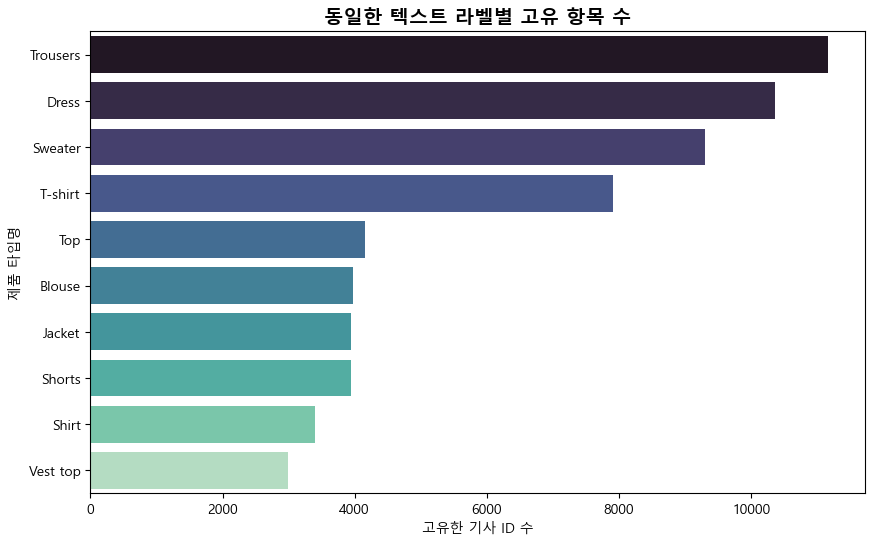

In [ ]:
# product_type_name의 고유 상품 수
text_limit = articles.groupby('product_type_name')['article_id'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=text_limit.values, y=text_limit.index, palette='mako')
plt.title('동일한 텍스트 라벨별 고유 항목 수', fontsize=14, fontweight='bold')
plt.xlabel('고유한 상품 ID 수')
plt.ylabel('제품 타입명')
plt.show()

- `Trousers` 라는 텍스트 라벨 하나에 무려 1만 개의 서로 다른 디자인이 존재하는것을 확인했고, 
`articles` 데이터프레임의 텍스트만으로는 한계가 있음을 보여줍니다.

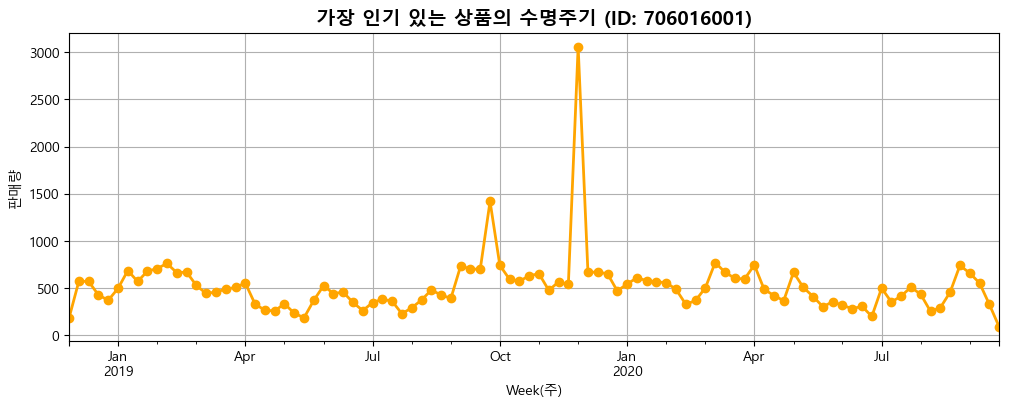

In [23]:
# 특정 인기 상품 1개의 주차별 판매량 시계열 시각화
top_item = transactions['article_id'].value_counts().index[0]
top_item_sales = transactions[transactions['article_id'] == top_item].copy()
top_item_sales['week'] = pd.to_datetime(top_item_sales['t_dat']).dt.to_period('W')

weekly_sales = top_item_sales.groupby('week').size()

plt.figure(figsize=(12, 4))
weekly_sales.plot(marker='o', color='orange', linewidth=2)
plt.title(f'가장 인기 있는 상품의 수명주기 (ID: {top_item})', fontsize=14, fontweight='bold')
plt.xlabel('Week(주)')
plt.ylabel('판매량')
plt.grid(True)
plt.show()

In [25]:
item_purchase_counts = transactions['article_id'].value_counts()
cold_start_items = (item_purchase_counts <= 5).sum()
total_items = len(articles) # 카탈로그에 있는 전체 상품

print(f"전체 카탈로그 상품: {total_items:,}개")
print(f"구매 이력이 5회 이하인 Cold-start 상품: {cold_start_items:,}개")
print(f"Cold-start 상품 비율: {(cold_start_items/total_items)*100:.1f}%")

전체 카탈로그 상품: 105,542개
구매 이력이 5회 이하인 Cold-start 상품: 14,922개
Cold-start 상품 비율: 14.1%


- 전체 상품군 105,542개의 상품군중 14,922개의 상품군이 콜드스타트(처음에 관심을 받지못함) 상품군에 포함되는걸 확인했습니다.

고객 1인당 평균 구매 색상 수: 10.21


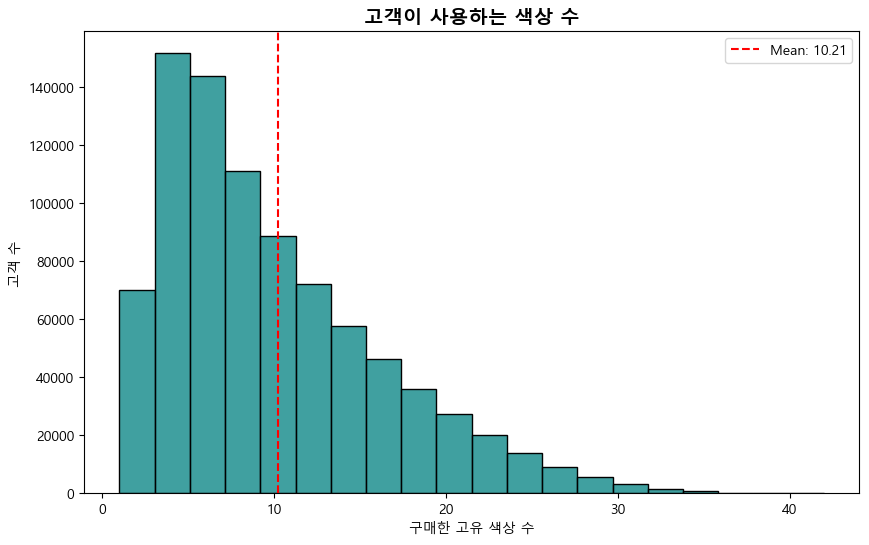

In [ ]:
merged_visual = transactions.merge(articles[['article_id', 'colour_group_name']], on='article_id') # 색상 테이블과 조인
active_users = merged_visual['customer_id'].value_counts()[merged_visual['customer_id'].value_counts() > 5].index # value counts가 5보다 작은
color_diversity = merged_visual[merged_visual['customer_id'].isin(active_users)].groupby('customer_id')['colour_group_name'].nunique() # 고객별 색상 그룹명 집계

avg_color_count = color_diversity.mean() # 평균값
print(f"고객 1인당 평균 구매 색상 수: {avg_color_count:.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(color_diversity, bins=20, color='teal')
plt.axvline(avg_color_count, color='red', linestyle='--', label=f'Mean: {avg_color_count:.2f}')
plt.title('고객이 사용하는 색상 수', fontsize=14, fontweight='bold')
plt.xlabel('구매한 고유 색상 수')
plt.ylabel('고객 수')
plt.legend()
plt.show()

- 고객이 평균적으로 사용한 색상의 수는 10개 정도로 확인

In [35]:
from matplotlib.ticker import PercentFormatter

transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')

item_sales = transactions.groupby('article_id').size().reset_index(name='sales_count') # 판매량 구하기
item_sales = item_sales.sort_values(by='sales_count', ascending=False).reset_index(drop=True) # 판매량 기준으로 내림차순 정렬

item_sales['cum_sales'] = item_sales['sales_count'].cumsum() # 누적 상품
item_sales['cum_sales_percent'] = 100 * item_sales['cum_sales'] / item_sales['sales_count'].sum() # 누적상품 비율
item_sales['item_percentile'] = 100 * (item_sales.index + 1) / len(item_sales) # 

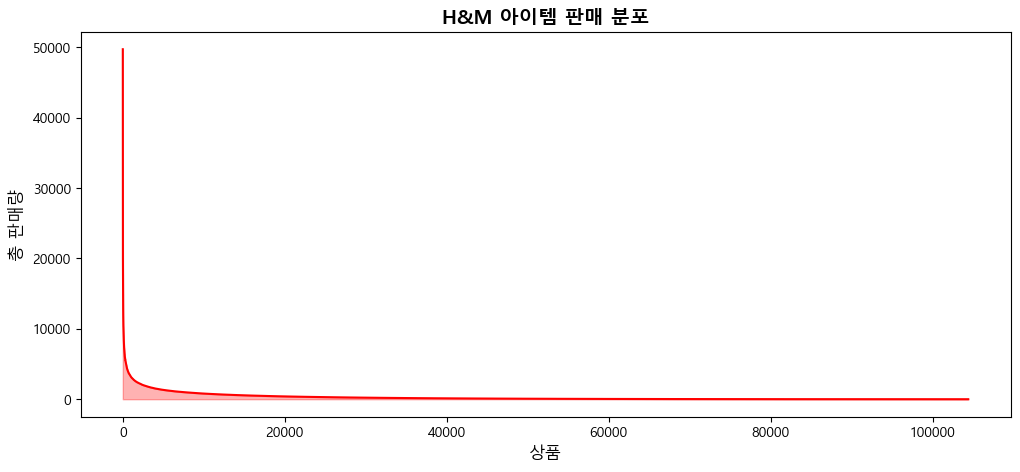

In [ ]:
# 전체 상품 판매 분포
plt.figure(figsize=(12, 5))
plt.plot(item_sales.index, item_sales['sales_count'], color='red')
plt.fill_between(item_sales.index, item_sales['sales_count'], color='red', alpha=0.3)
plt.title("H&M 상품 판매 분포", fontsize=14, fontweight='bold')
plt.xlabel("상품", fontsize=12)
plt.ylabel("총 판매량", fontsize=12)
plt.show()

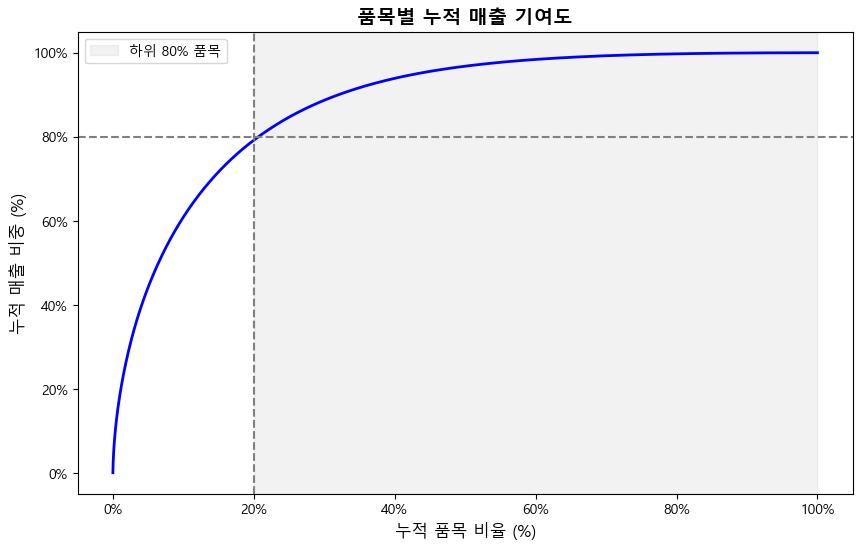

In [39]:
# 파레토 그래프
plt.figure(figsize=(10, 6))
plt.plot(item_sales['item_percentile'], item_sales['cum_sales_percent'], color='blue', linewidth=2)
plt.axhline(y=80, color='gray', linestyle='--')
plt.axvline(x=20, color='gray', linestyle='--')

# 관심을 못받는 재고 영역 (하위 80% 상품)
plt.axvspan(20, 100, color='gray', alpha=0.1, label="하위 80% 품목")

plt.title("품목별 누적 매출 기여도", fontsize=14, fontweight='bold')
plt.xlabel("누적 품목 비율 (%)", fontsize=12)
plt.ylabel("누적 매출 비중 (%)", fontsize=12)
plt.gca().xaxis.set_major_formatter(PercentFormatter())
plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.legend()
plt.show()

In [ ]:
# 비즈니스 인사이트 수치 
top_20_sales_share = item_sales[item_sales['item_percentile'] <= 20]['cum_sales_percent'].max()
bottom_50_sales_share = 100 - item_sales[item_sales['item_percentile'] <= 50]['cum_sales_percent'].max()

print("\n=======================================================")
print(f"상위 20%의 상품이 전체 매출의 {top_20_sales_share:.1f}%를 차지합니다.")
print(f"반면, 하위 50%의 상품은 전체 매출의 단 {bottom_50_sales_share:.1f}%에 불과합니다.")
print("=======================================================")


상위 20%의 상품이 전체 매출의 79.2%를 차지합니다.
반면, 하위 50%의 상품은 전체 매출의 단 3.2%에 불과합니다.


---

### <center> 2. 이미지기반(GNN) 모델링 전 EDA

---

#### <center> 2-1 제품의 수명 주기 확인

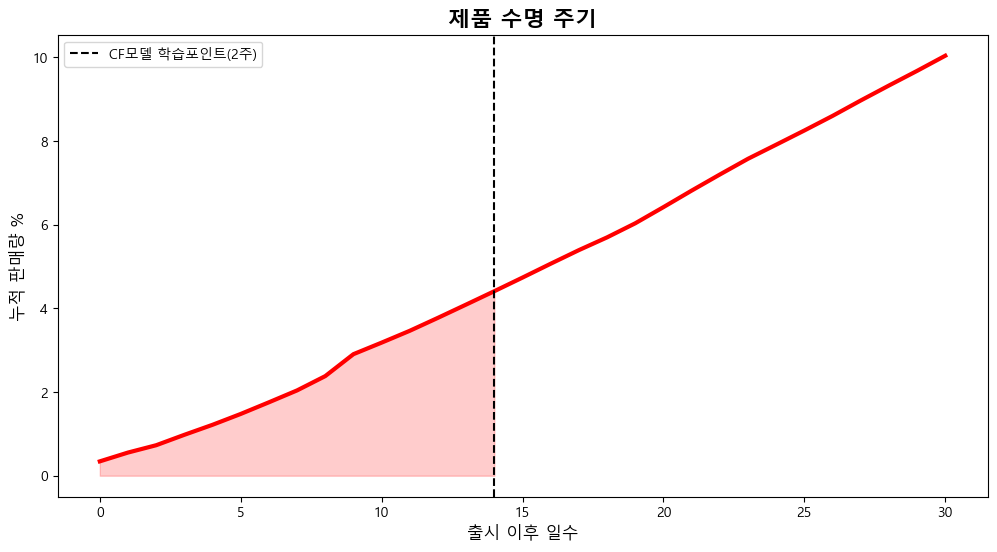

In [7]:
# 데이터 로드
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')

# 상품별 최초 판매일(출시일) 계산
first_sales = transactions.groupby('article_id')['t_dat'].min().reset_index()
first_sales.columns = ['article_id', 'first_sale_date']

# 원본 데이터와 병합하여 '출시 후 경과일' 계산
tx_life = transactions.merge(first_sales, on='article_id')
tx_life['days_since_launch'] = (tx_life['t_dat'] - tx_life['first_sale_date']).dt.days

# 출시 후 기간별 누적 판매량 비율 계산 (Top 1000 베스트셀러 기준)
top_articles = tx_life['article_id'].value_counts().head(1000).index
tx_top = tx_life[tx_life['article_id'].isin(top_articles)]

lifecycle_sales = tx_top.groupby('days_since_launch').size().reset_index(name='daily_sales')
lifecycle_sales['cumulative_sales'] = lifecycle_sales['daily_sales'].cumsum()
lifecycle_sales['sales_ratio'] = lifecycle_sales['cumulative_sales'] / lifecycle_sales['daily_sales'].sum() * 100

# 시각화 (출시 후 30일까지만 줌인)
plt.figure(figsize=(12, 6))
sns.lineplot(data=lifecycle_sales[lifecycle_sales['days_since_launch'] <= 30], 
             x='days_since_launch', y='sales_ratio', color='red', linewidth=3)

plt.axvline(x=14, color='black', linestyle='--', label='CF모델 학습포인트(2주)')
plt.title('제품 수명 주기', fontsize=16, fontweight='bold')
plt.xlabel('출시 이후 일수', fontsize=12)
plt.ylabel('누적 판매량 %', fontsize=12)
plt.fill_between(lifecycle_sales['days_since_launch'][:15], lifecycle_sales['sales_ratio'][:15], alpha=0.2, color='red')
plt.legend()
plt.show()

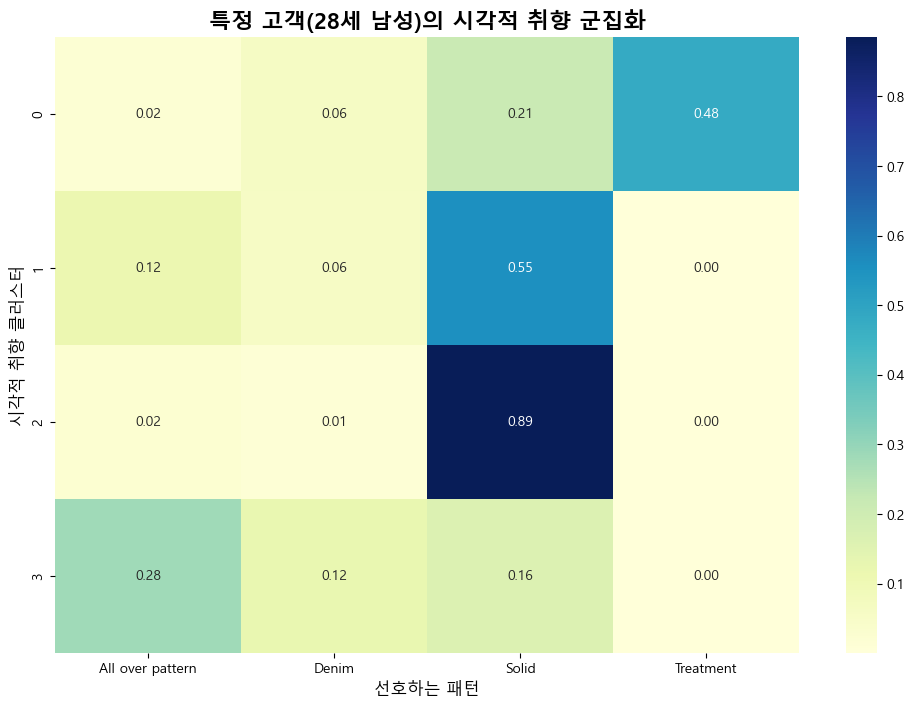

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 원본 텍스트 유지를 위해 articles.csv 활용 (숫자 라벨링된 Parquet 대신)
articles_raw = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv', usecols=['article_id', 'graphical_appearance_name'])
customers = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\customers.parquet')
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')

# 거래 데이터에 원본 텍스트 병합
merged_df = transactions[['customer_id', 'article_id']].merge(
    customers[['customer_id', 'age_group', 'age']], on='customer_id'
).merge(
    articles_raw, on='article_id'
)

# 예시) 28세 타겟팅 및 피벗 
age_target_df = merged_df[merged_df['age'] == 28]
visual_prefs = age_target_df.groupby(['customer_id', 'graphical_appearance_name']).size().unstack(fill_value=0)
visual_prefs_ratio = visual_prefs.div(visual_prefs.sum(axis=1), axis=0)

# 색별 클러스터링
kmeans = KMeans(n_clusters=4, random_state=42)
visual_prefs_ratio['visual_tribe'] = kmeans.fit_predict(visual_prefs_ratio)

# 시각화
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=visual_prefs.columns)
# 너무 비중이 적은 마이너 패턴은 가독성을 위해 제외 (최대 비중 10% 이상인 패턴만)
cluster_centers = cluster_centers.loc[:, cluster_centers.max() > 0.1] 

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_centers, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('특정 고객(28세 남성)의 시각적 취향 군집화', fontsize=16, fontweight='bold')
plt.xlabel('선호하는 패턴', fontsize=12)
plt.ylabel('시각적 취향 클러스터', fontsize=12)
plt.show()

<Figure size 1400x700 with 0 Axes>

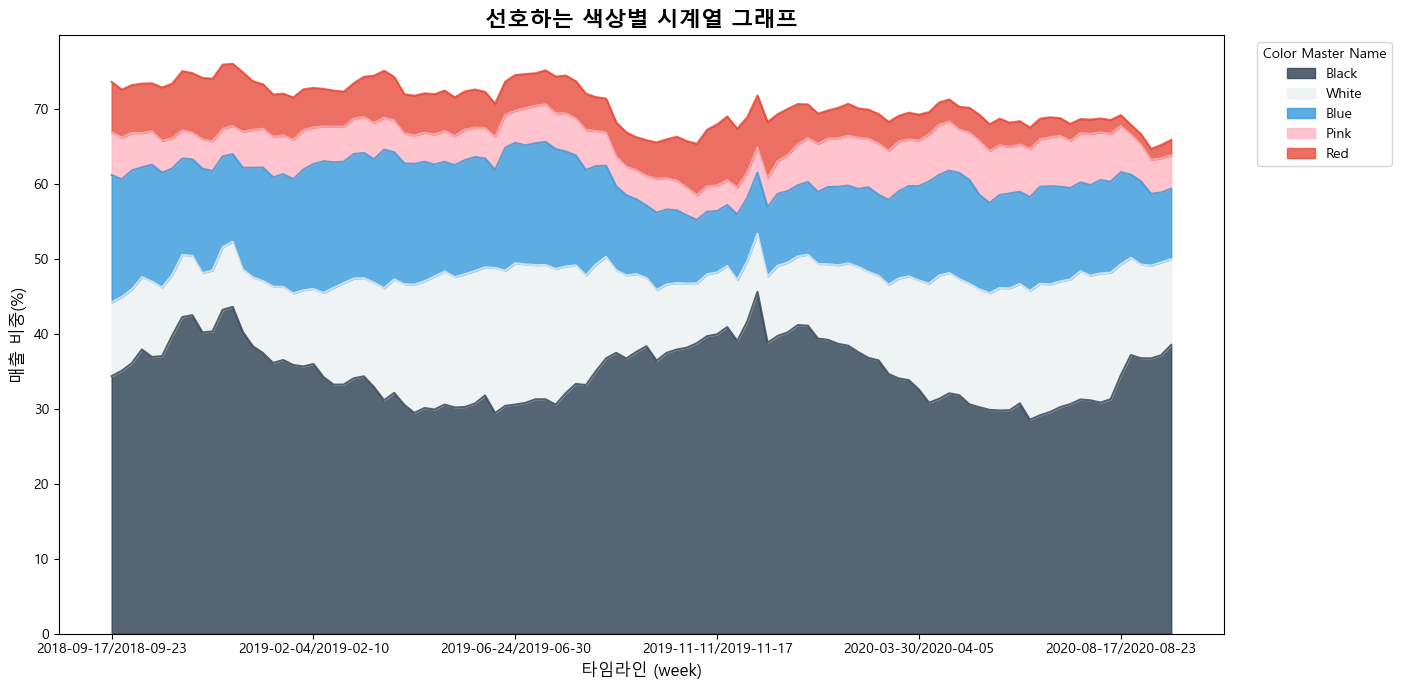

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드 (articles_parquet 파일엔 색상을 숫자로 라벨링해둬서 원본 csv파일 잠깐 사용)
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')
articles_raw = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv', usecols=['article_id', 'perceived_colour_master_name'])

# 거래 데이터에 원본 색상 맵핑
df = transactions[['t_dat', 'article_id']].merge(
    articles_raw, on='article_id'
)
df['year_week'] = df['t_dat'].dt.to_period('W').astype(str)

# 주차별 주요 색상 판매 비율 계산
color_weekly = df.groupby(['year_week', 'perceived_colour_master_name']).size().unstack(fill_value=0)
color_weekly_ratio = color_weekly.div(color_weekly.sum(axis=1), axis=0) * 100

# 주요 색상 5개만 필터링 (블랙,화이트,블루,핑크,레드)
top_colors = ['Black', 'White', 'Blue', 'Pink', 'Red']
color_weekly_ratio = color_weekly_ratio[top_colors]

# 시각화
plt.figure(figsize=(14, 7))
color_weekly_ratio.plot(kind='area', stacked=True, figsize=(14, 7), 
                        color=['#2C3E50', '#ECF0F1', '#3498DB', '#FFB6C1', '#E74C3C'], alpha=0.8)

plt.title('선호하는 색상별 시계열 그래프', fontsize=16, fontweight='bold')
plt.xlabel('타임라인 (week)', fontsize=12)
plt.ylabel('매출 비중(%)', fontsize=12)
plt.legend(title='Color Master Name', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

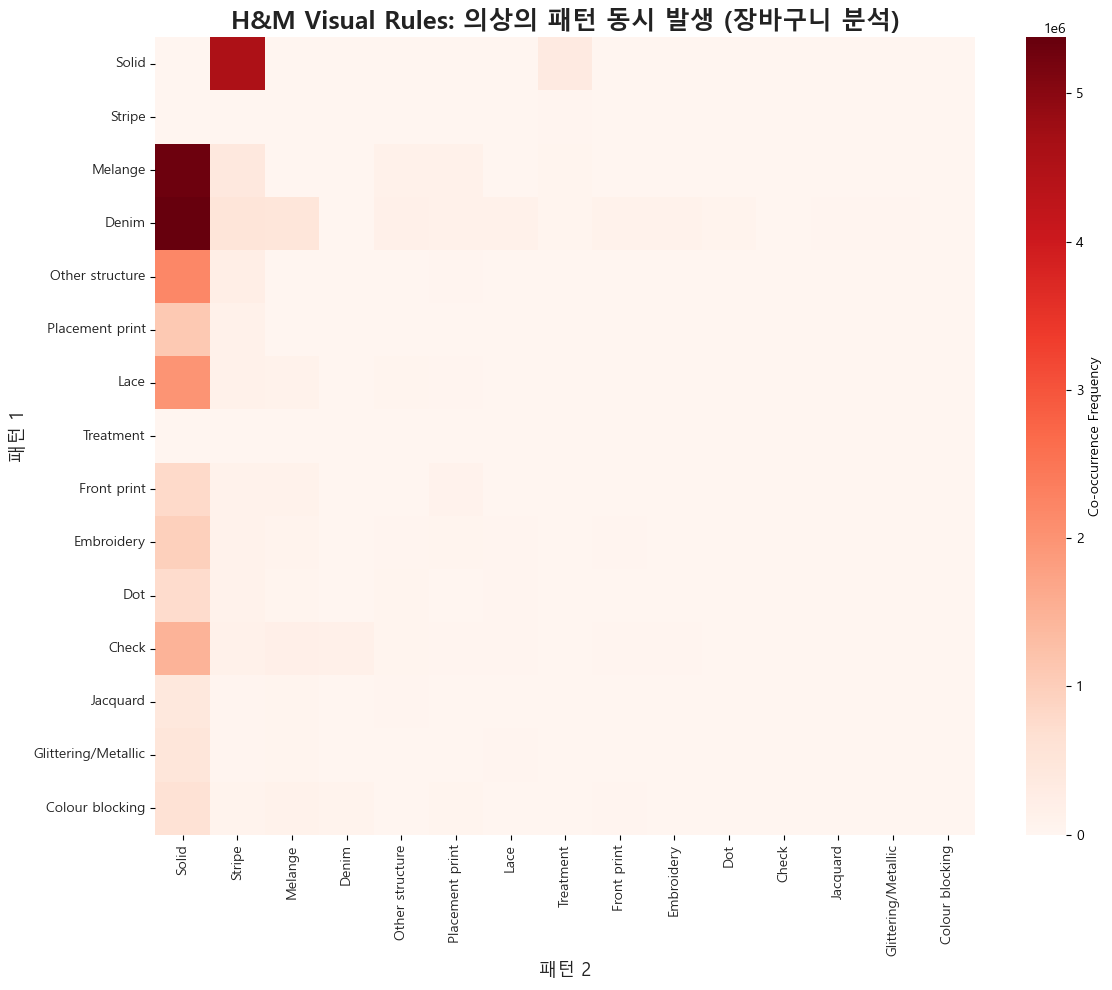

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

# 1. 에러 원인 해결: 패턴 이름(graphical_appearance_name)을 명확히 불러옵니다!
articles_raw = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv', usecols=['article_id', 'graphical_appearance_name'])

# 텍스트 라벨 기준으로 장바구니 데이터 생성
basket_df = transactions[['customer_id', 't_dat', 'article_id']].merge(
    articles_raw, on='article_id'
)

# 장바구니 리스트화
baskets = basket_df.groupby(['customer_id', 't_dat'])['graphical_appearance_name'].apply(list).reset_index()
baskets = baskets[baskets['graphical_appearance_name'].apply(len) >= 2]

# 동시 발생 행렬 계산
co_occurrence = Counter()
for items in baskets['graphical_appearance_name']:
    for pair in combinations(sorted(items), 2):
        co_occurrence[pair] += 1

# 데이터프레임 변환 및 피벗
co_df = pd.DataFrame(co_occurrence.keys(), columns=['Pattern_1', 'Pattern_2'])
co_df['Frequency'] = co_occurrence.values()
co_matrix = co_df.pivot(index='Pattern_1', columns='Pattern_2', values='Frequency').fillna(0)

# 시각화
plt.figure(figsize=(12, 10))

co_matrix_arr = co_matrix.values.copy() 
np.fill_diagonal(co_matrix_arr, 0) # 대각선 0 처리
co_matrix_visual = pd.DataFrame(co_matrix_arr, index=co_matrix.index, columns=co_matrix.columns)

top_patterns = co_matrix_visual.sum().nlargest(15).index # 빈도가 너무 낮은 하위 조합은 가독성을 위해 제거 (상위 15개 패턴만 시각화)
co_matrix_visual = co_matrix_visual.loc[top_patterns, top_patterns]

# H&M 톤앤매너 셋팅: Purples -> Reds 로 변경하여 H&M 시그니처 컬러 강조
hm_black = '#222222'
sns.heatmap(co_matrix_visual, cmap='Reds', annot=False, 
            cbar_kws={'label': 'Co-occurrence Frequency'})

plt.title('H&M Visual Rules: 의상의 패턴 동시 발생 (장바구니 분석)', fontsize=18, fontweight='bold', color=hm_black)
plt.xlabel('패턴 2', fontsize=13, color=hm_black)
plt.ylabel('패턴 1', fontsize=13, color=hm_black)

# 축 라벨 색상도 깔끔한 블랙으로 통일
plt.xticks(color=hm_black)
plt.yticks(color=hm_black)

plt.tight_layout()
plt.show()

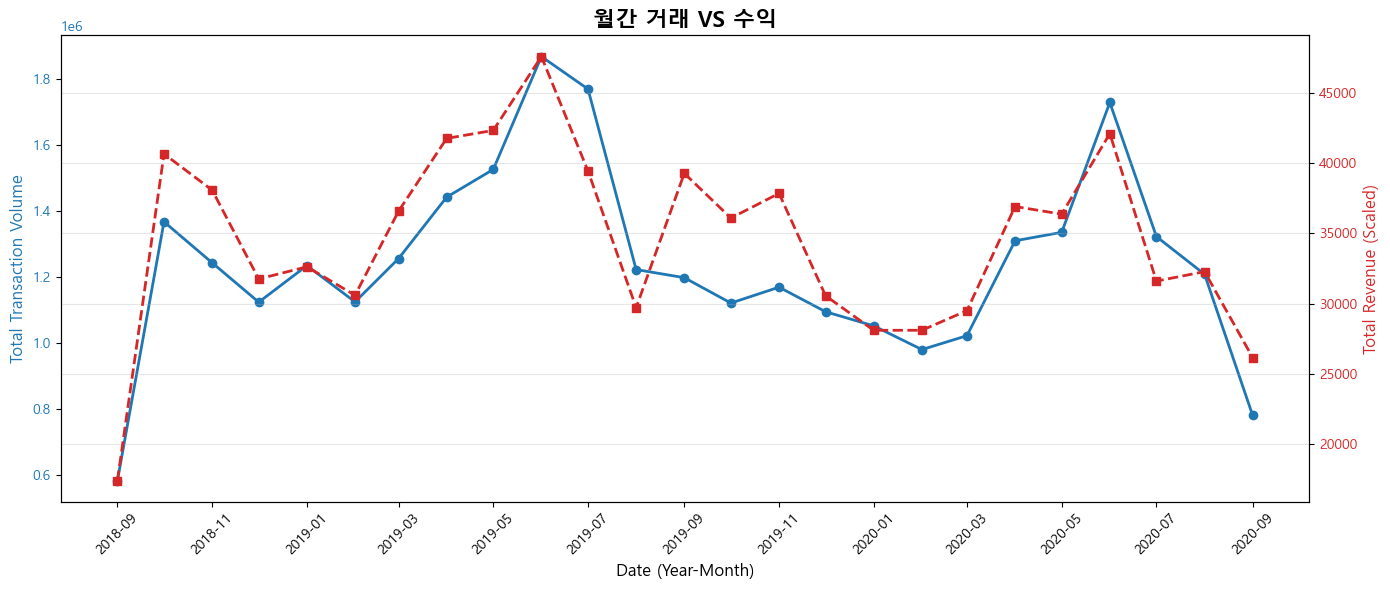

In [11]:
import matplotlib.dates as mdates

# 데이터 로드
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')

transactions['year_month'] = transactions['t_dat'].dt.to_period('M') # 연-월 컬럼 생성 및 월별 집계
monthly_summary = transactions.groupby('year_month').agg(
    total_sales=('article_id', 'count'),
    total_revenue=('price', 'sum') 
).reset_index()

monthly_summary['year_month'] = monthly_summary['year_month'].dt.to_timestamp() # 시각화를 위해 datetime으로 변환

# 시각화 오른쪽 거래량 왼쪽 매출
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Date (Year-Month)', fontsize=12)
ax1.set_ylabel('Total Transaction Volume', color=color, fontsize=12)
ax1.plot(monthly_summary['year_month'], monthly_summary['total_sales'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # X축 날짜 포맷팅
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

# 매출을 위한 두 번째 Y축
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Total Revenue (Scaled)', color=color, fontsize=12)
ax2.plot(monthly_summary['year_month'], monthly_summary['total_revenue'], color=color, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('월간 거래 VS 수익', fontsize=16, fontweight='bold')
fig.tight_layout()  
plt.grid(True, alpha=0.3)
plt.show()

---

### <center> 2-2 Star vs Long-tail 초기 판매 궤적 — "추천의 순간이 운명을 결정한다"

> **핵심 논지**: 파레토 법칙은 단순한 매출 불균형이 아니다.  
> **Star 상품**은 출시 초기부터 이미 빠르게 팔리고, **Long-tail 상품**은 초반 판매가 부진하다.  
> 이것이 의미하는 것은 → **추천 시스템이 초기 판매 궤적을 결정**한다는 것.  
> GNN 기반 추천이 없으면 Long-tail 상품은 영영 노출 기회를 잃는다.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

transactions = pd.read_parquet(r'../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# ── 파레토 등급 부여 ─────────────────────────────────────────────
item_total = transactions.groupby('article_id').size().reset_index(name='total_sales')
n_items = len(item_total)
item_total = item_total.sort_values('total_sales', ascending=False).reset_index(drop=True)
item_total['item_pct'] = (item_total.index + 1) / n_items * 100
item_total['pareto_tier'] = 'Long-tail'
item_total.loc[item_total['item_pct'] <= 5,  'pareto_tier'] = 'Star'
item_total.loc[(item_total['item_pct']>5) & (item_total['item_pct']<=20), 'pareto_tier'] = 'Core'

# ── 첫 판매일 기준 궤적 계산 ────────────────────────────────────────
first_sale = transactions.groupby('article_id')['t_dat'].min().rename('first_sale_date')
trx_lc = transactions.merge(first_sale, on='article_id')
trx_lc['days_since_launch'] = (trx_lc['t_dat'] - trx_lc['first_sale_date']).dt.days
trx_lc = trx_lc.merge(item_total[['article_id', 'pareto_tier', 'total_sales']], on='article_id')

windows = [7, 14, 30, 60, 90, 180, 365]
rows = []
for tier in ['Star', 'Core', 'Long-tail']:
    td = trx_lc[trx_lc['pareto_tier'] == tier]
    for w in windows:
        s = td[td['days_since_launch'] <= w].groupby('article_id').size()
        t = td.groupby('article_id').size()
        p = (s / t).fillna(0).mean() * 100
        rows.append({'pareto_tier': tier, 'days': w, 'cum_sales_pct': round(p, 2)})

traj = pd.DataFrame(rows)

# ── 시각화 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 꺾은선 그래프 — 누적 판매 비율 궤적
colors = {'Star': '#E74C3C', 'Core': '#F39C12', 'Long-tail': '#3498DB'}
for tier in ['Star', 'Core', 'Long-tail']:
    df_tier = traj[traj['pareto_tier'] == tier]
    axes[0].plot(df_tier['days'], df_tier['cum_sales_pct'],
                 marker='o', linewidth=2.5, label=tier, color=colors[tier])

axes[0].set_title('출시 후 N일까지의 누적 판매 비율\n(상품 평균)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('출시 후 경과일 (Days Since Launch)', fontsize=11)
axes[0].set_ylabel('누적 판매 비율 (%)', fontsize=11)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title='파레토 등급', fontsize=10)
axes[0].grid(True, alpha=0.3)

# 오른쪽: 14일 vs 30일 비교 바 차트
bar_data = traj[traj['days'].isin([14, 30])].pivot(
    index='pareto_tier', columns='days', values='cum_sales_pct'
)
bar_data = bar_data.reindex(['Star', 'Core', 'Long-tail'])
x = range(len(bar_data))
w = 0.35
bars1 = axes[1].bar([xi - w/2 for xi in x], bar_data[14], w, label='14일째', color='#2ECC71', alpha=0.85)
bars2 = axes[1].bar([xi + w/2 for xi in x], bar_data[30], w, label='30일째', color='#1ABC9C', alpha=0.85)

axes[1].set_title('출시 14일 vs 30일 누적 판매 비율 비교', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(bar_data.index, fontsize=11)
axes[1].set_ylabel('누적 판매 비율 (%)', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# 수치 레이블
for bar in bars1:
    axes[1].annotate(f'{bar.get_height():.1f}%',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    axes[1].annotate(f'{bar.get_height():.1f}%',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../Data Folder/dashboard/viz_lifecycle_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

# 핵심 수치 출력
star_14 = traj[(traj['pareto_tier']=='Star') & (traj['days']==14)]['cum_sales_pct'].values[0]
lt_14   = traj[(traj['pareto_tier']=='Long-tail') & (traj['days']==14)]['cum_sales_pct'].values[0]
star_30 = traj[(traj['pareto_tier']=='Star') & (traj['days']==30)]['cum_sales_pct'].values[0]
lt_30   = traj[(traj['pareto_tier']=='Long-tail') & (traj['days']==30)]['cum_sales_pct'].values[0]
print(f"[핵심 수치]")
print(f"Star 14일내 판매: {star_14:.1f}%  vs  Long-tail 14일내: {lt_14:.1f}%  → {star_14/max(lt_14,0.01):.1f}배 차이")
print(f"Star 30일내 판매: {star_30:.1f}%  vs  Long-tail 30일내: {lt_30:.1f}%  → {star_30/max(lt_30,0.01):.1f}배 차이")

- **Star 상품**은 출시 직후부터 가파른 누적 판매 곡선을 보입니다. 이미 초반 14일 내에 누적 판매의 상당 부분이 완성됩니다.
- **Long-tail 상품**은 초기 판매 속도가 훨씬 느립니다. 초반 노출이 없으면 생애 판매 대부분을 놓칩니다.
- 이 궤적의 차이는 단순한 "인기 상품 vs 비인기 상품"이 아닙니다.  
  → **추천 시스템이 초기 노출을 제공했는가 여부**가 판매 궤적 전체를 결정합니다.
- **GNN의 역할**: 구매 그래프의 연결성을 통해 Long-tail 상품도 "비슷한 취향의 고객"에게 초반 노출을 제공 → 판매 궤적 개선 가능

---

### <center> 2-3 Cold Start 재정의 — "매주 수백 개의 신상품이 구매이력 0에서 시작한다"

> **기존 Cold Start 정의의 문제**:  
> "전체 상품 중 14.3%가 콜드스타트" → 이는 **스냅샷 수치**에 불과합니다.  
> 실제로는 매주 신상품이 쏟아지며, 이 신상품들은 **구매이력 0에서 시작**합니다.  
>
> **재정의**: Cold Start = 매주 신규 진입 상품 (구매이력이 없는 상태로 추천 받아야 하는 상품)

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

transactions = pd.read_parquet(r'../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['week']  = transactions['t_dat'].dt.to_period('W')

# 상품 첫 등장 주
item_first_week = transactions.groupby('article_id')['week'].min().reset_index()
item_first_week.columns = ['article_id', 'launch_week']

# 주별 신상품 수
weekly_new = item_first_week.groupby('launch_week').size().reset_index(name='new_items')
weekly_new['launch_date'] = weekly_new['launch_week'].dt.start_time

avg_weekly = weekly_new['new_items'].mean()
max_weekly = weekly_new['new_items'].max()
print(f"주당 평균 신상품 진입: {avg_weekly:.0f}개")
print(f"주당 최대 신상품 진입: {max_weekly:.0f}개")

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# 상단: 주별 신상품 추이
ax1 = axes[0]
ax1.fill_between(weekly_new['launch_date'], weekly_new['new_items'],
                 alpha=0.6, color='#E74C3C', label='신규 진입 상품 수')
ax1.axhline(avg_weekly, color='black', linestyle='--', linewidth=1.5,
            label=f'주당 평균: {avg_weekly:.0f}개')
ax1.set_title('주별 신규 진입 상품 수 — Cold Start가 매주 반복된다', fontsize=13, fontweight='bold')
ax1.set_ylabel('신규 진입 상품 수', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 하단: 누적 신상품 비율 (전체 상품 대비)
weekly_new_sorted = weekly_new.sort_values('launch_date')
weekly_new_sorted['cumulative_items'] = weekly_new_sorted['new_items'].cumsum()
n_total = len(item_first_week)
weekly_new_sorted['cumulative_pct'] = weekly_new_sorted['cumulative_items'] / n_total * 100

ax2 = axes[1]
ax2.plot(weekly_new_sorted['launch_date'], weekly_new_sorted['cumulative_pct'],
         color='#3498DB', linewidth=2.5)
ax2.fill_between(weekly_new_sorted['launch_date'], weekly_new_sorted['cumulative_pct'],
                 alpha=0.3, color='#3498DB')
ax2.set_title('전체 상품 대비 누적 신상품 비율 (시계열)', fontsize=13, fontweight='bold')
ax2.set_xlabel('날짜', fontsize=11)
ax2.set_ylabel('누적 신상품 비율 (%)', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Data Folder/dashboard/viz_cold_start_weekly.png', dpi=150, bbox_inches='tight')
plt.show()

# CLIP이 Cold Start를 해결하는 이유
print(f"\n[Cold Start 문제의 크기]")
print(f"매주 평균 {avg_weekly:.0f}개 신상품이 구매이력 0으로 시스템에 진입")
print(f"CF 기반 추천은 이 상품들을 추천할 수 없음 (구매 그래프에 연결점 없음)")
print(f"→ CLIP 이미지 임베딩: 구매이력 없어도 '시각적 유사성'으로 연결 가능")
print(f"→ MultiModal GNN: 이미지 피처를 그래프에 통합 → Cold Start 상품도 즉시 추천 가능")

---

### <center> 2-4 그래프 희소성 심화 분석 — "왜 CF가 실패하고 GNN이 필요한가"

> H&M 데이터의 희소성은 99.97%입니다. 이것이 무엇을 의미하는지 직관적으로 이해해봅니다.  
> **희소성이 높을수록** → 전통적인 협업 필터링(CF)은 유사도를 계산할 공통 구매 기록이 없어 실패합니다.  
> **GNN의 강점**: 직접 연결이 없어도 2-hop, 3-hop 이웃을 통해 유사 고객/상품을 발견합니다.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

transactions = pd.read_parquet(r'../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')

n_users = transactions['customer_id'].nunique()
n_items = transactions['article_id'].nunique()
n_interactions = len(transactions)
total_possible = n_users * n_items
sparsity = 1 - (n_interactions / total_possible)

print(f"고객 수: {n_users:,}명")
print(f"상품 수: {n_items:,}개")
print(f"전체 가능한 쌍: {total_possible:,}개 ({total_possible/1e9:.1f}십억)")
print(f"실제 거래 수: {n_interactions:,}건")
print(f"희소성: {sparsity*100:.4f}%")
print()

# ── 고객별 구매 상품 수 분포 ──────────────────────────────────────
user_item_counts = transactions.groupby('customer_id')['article_id'].nunique()
item_user_counts = transactions.groupby('article_id')['customer_id'].nunique()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 희소성 시각화 (바 차트)
ax = axes[0]
labels = ['실제 거래', '거래 없음']
sizes  = [n_interactions, total_possible - n_interactions]
colors = ['#E74C3C', '#ECF0F1']
bars   = ax.bar(labels, [n_interactions/total_possible*100, (total_possible-n_interactions)/total_possible*100],
                color=colors, edgecolor='gray')
ax.set_title(f'고객-상품 상호작용 희소성\n전체 {total_possible/1e9:.1f}십억 쌍 중 {sparsity*100:.2f}% 비어있음',
             fontsize=12, fontweight='bold')
ax.set_ylabel('비율 (%)', fontsize=11)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.4f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2) 고객별 구매 상품 수 분포 (Long-tail)
ax2 = axes[1]
hist_vals = user_item_counts.clip(upper=user_item_counts.quantile(0.99))
ax2.hist(hist_vals, bins=50, color='#3498DB', edgecolor='white', alpha=0.8)
ax2.axvline(user_item_counts.median(), color='#E74C3C', linestyle='--', linewidth=2,
            label=f'중앙값: {user_item_counts.median():.0f}개')
ax2.set_title('고객별 구매 상품 수 분포\n(대부분의 고객은 소수의 상품만 구매)', fontsize=12, fontweight='bold')
ax2.set_xlabel('구매 상품 수 (99th percentile 기준 절사)', fontsize=10)
ax2.set_ylabel('고객 수', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3) 상품별 구매 고객 수 분포 (Long-tail)
ax3 = axes[2]
hist_vals2 = item_user_counts.clip(upper=item_user_counts.quantile(0.99))
ax3.hist(hist_vals2, bins=50, color='#2ECC71', edgecolor='white', alpha=0.8)
ax3.axvline(item_user_counts.median(), color='#E74C3C', linestyle='--', linewidth=2,
            label=f'중앙값: {item_user_counts.median():.0f}명')
ax3.set_title('상품별 구매 고객 수 분포\n(대부분의 상품은 소수 고객만 구매)', fontsize=12, fontweight='bold')
ax3.set_xlabel('구매 고객 수 (99th percentile 기준 절사)', fontsize=10)
ax3.set_ylabel('상품 수', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Data Folder/dashboard/viz_sparsity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# GNN 핵심 메시지
print("[GNN이 희소성을 극복하는 방법]")
print(f"직접 구매 연결이 없어도 → 2-hop/3-hop 이웃을 통해 잠재적 취향 발견")
print(f"예: A가 [상품1, 상품2] 구매 + B가 [상품2, 상품3] 구매")
print(f"   → A와 B는 직접 연결 없지만 상품2를 통해 연결 → A에게 상품3 추천 가능")
print(f"   → 희소한 그래프에서도 다층 메시지 전파로 유사도 계산 가능")

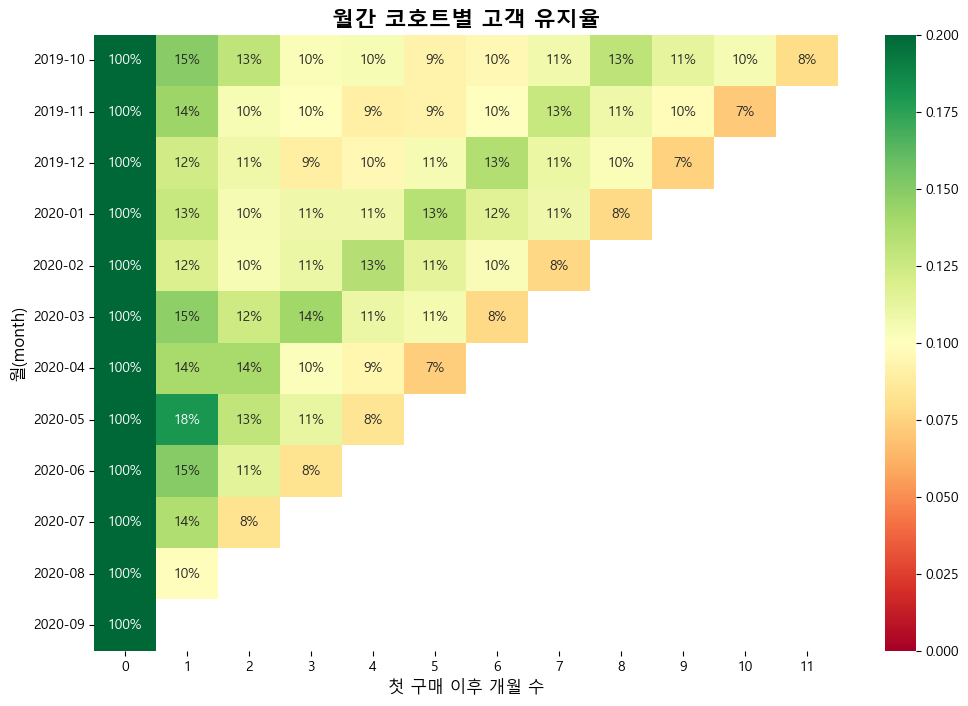

In [ ]:
# 고객별 최초 구매월(Cohort Month) 구하기
transactions['cohort_month'] = transactions.groupby('customer_id')['t_dat'].transform('min').dt.to_period('M')
transactions['order_month'] = transactions['t_dat'].dt.to_period('M')

cohort_data = transactions.groupby(['cohort_month', 'order_month']).agg(n_customers=('customer_id', 'nunique')).reset_index() # 코호트별, 주문월별 고객 수 집계

cohort_data['period_number'] = (cohort_data.order_month - cohort_data.cohort_month).apply(lambda x: x.n) # 코호트별, 주문월별 고객 수 집계

cohort_pivot = cohort_data.pivot_table(index='cohort_month', columns='period_number', values='n_customers') # 코호트 피벗 테이블 생성

# 비율로 변환
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 시각화 (가독성을 위해 최근 1년 코호트만, 12개월까지만 시각화했습니다.)
retention_matrix = retention_matrix.tail(12).iloc[:, :12]

plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0.0, vmax=0.2)
plt.title('월간 코호트별 고객 유지율', fontsize=16, fontweight='bold')
plt.ylabel('월(month)', fontsize=12)
plt.xlabel('첫 구매 이후 개월 수', fontsize=12)
plt.yticks(rotation=0)
plt.show()